# NLP: Bag of Words, N-grams and TF-IDF

In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
import matplotlib.pyplot as plt
corpus=['Natural language processing is fun','Machine learning is fun','Natural language processing uses text data']

## Create a Bag of Words representation

In [19]:
cv=CountVectorizer();
X=cv.fit_transform(corpus);
print(X.toarray())

[[0 1 1 1 0 0 1 1 0 0]
 [0 1 1 0 1 1 0 0 0 0]
 [1 0 0 1 0 0 1 1 1 1]]


## Count word frequencies

In [3]:
print(Counter(' '.join(corpus).lower().split()))

Counter({'natural': 2, 'language': 2, 'processing': 2, 'is': 2, 'fun': 2, 'machine': 1, 'learning': 1, 'uses': 1, 'text': 1, 'data': 1})


## Generate unigrams

In [4]:
print(CountVectorizer(ngram_range=(1,1)).fit(corpus).get_feature_names_out())

['data' 'fun' 'is' 'language' 'learning' 'machine' 'natural' 'processing'
 'text' 'uses']


## Generate bigrams

In [5]:
print(CountVectorizer(ngram_range=(2,2)).fit(corpus).get_feature_names_out())

['is fun' 'language processing' 'learning is' 'machine learning'
 'natural language' 'processing is' 'processing uses' 'text data'
 'uses text']


## Generate trigrams

In [6]:
print(CountVectorizer(ngram_range=(3,3)).fit(corpus).get_feature_names_out())

['language processing is' 'language processing uses' 'learning is fun'
 'machine learning is' 'natural language processing' 'processing is fun'
 'processing uses text' 'uses text data']


## Build a TF-IDF vector

In [7]:
tf=TfidfVectorizer();print(tf.fit_transform(corpus).toarray())

[[0.         0.4472136  0.4472136  0.4472136  0.         0.
  0.4472136  0.4472136  0.         0.        ]
 [0.         0.42804604 0.42804604 0.         0.5628291  0.5628291
  0.         0.         0.         0.        ]
 [0.45954803 0.         0.         0.34949812 0.         0.
  0.34949812 0.34949812 0.45954803 0.45954803]]


## Find highest TF-IDF word

In [8]:
import numpy as np
tf=TfidfVectorizer();X=tf.fit_transform(corpus);print(tf.get_feature_names_out()[X.toarray().max(axis=0).argmax()])

learning


## Compare BoW vs TF-IDF dimensions

In [9]:
print(CountVectorizer().fit_transform(corpus).shape,TfidfVectorizer().fit_transform(corpus).shape)

(3, 10) (3, 10)


## Convert text into numerical vectors

In [10]:
print(CountVectorizer().fit_transform(corpus).toarray())

[[0 1 1 1 0 0 1 1 0 0]
 [0 1 1 0 1 1 0 0 0 0]
 [1 0 0 1 0 0 1 1 1 1]]


## Find vocabulary size

In [11]:
cv=CountVectorizer();cv.fit(corpus);print(len(cv.vocabulary_))

10


## Remove rare words

In [12]:
c=Counter(' '.join(corpus).lower().split());print([w for w,v in c.items() if v>1])

['natural', 'language', 'processing', 'is', 'fun']


## Remove highly frequent words

In [13]:
c=Counter(' '.join(corpus).lower().split());print([w for w,v in c.items() if v<3])

['natural', 'language', 'processing', 'is', 'fun', 'machine', 'learning', 'uses', 'text', 'data']


## Display document-term matrix shape

In [14]:
print(CountVectorizer().fit_transform(corpus).shape)

(3, 10)


## Count vocabulary before and after preprocessing

In [ ]:
import string
text=' '.join(corpus).lower();
before=len(set(text.split()));
after=len(set(text.translate(str.maketrans('','',string.punctuation)).split()));
print(before,after)

10 10


## Visualize top 10 frequent words

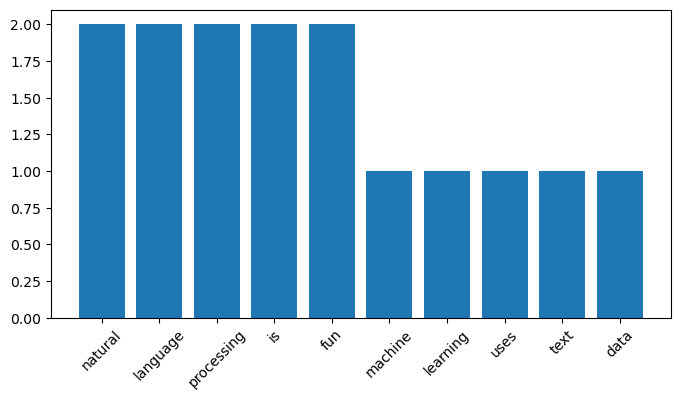

In [ ]:
c=Counter(' '.join(corpus).lower().split());top=c.most_common(10);
w,f=zip(*top);
plt.figure(figsize=(8,4));
plt.bar(w,f);
plt.xticks(rotation=45);
plt.show()